# Complete KNN Pipeline (From Scratch)

## Step 1: Loads CIFAR-10 Dataset

In [1]:
#imports modules
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from PIL import Image
import warnings

In [2]:
#function to extract images from CIFAR-10 readme
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [3]:
#function to extract images from CIFAR-10 readme - extracts only data and labels in x,y format
my_keys = [b'data',b'labels']
def unpickle_mod(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
        dict = {key:dict[key] for key in my_keys}
    return dict

In [4]:
#reads and 'unfolds' data from CIFAR-10 using helper function above
base_dir = r"/home/disk_2/Coding/CS231N/datasets/CIFAR10/cifar-10-python/cifar-10-batches-py/"
b1 = unpickle(base_dir + r"data_batch_1") 
b2 = unpickle(base_dir + r"data_batch_2")
b3 = unpickle(base_dir + r"data_batch_3")
b4 = unpickle(base_dir + r"data_batch_4")
b5 = unpickle(base_dir + r"data_batch_5")

In [5]:
#reads and 'unfolds' data from CIFAR-10 using helper function above - only x and y components
b1_mod = unpickle_mod(base_dir + r"data_batch_1") 
b2_mod = unpickle_mod(base_dir + r"data_batch_2")
b3_mod = unpickle_mod(base_dir + r"data_batch_3")
b4_mod = unpickle_mod(base_dir + r"data_batch_4")
b5_mod = unpickle_mod(base_dir + r"data_batch_5")

In [6]:
#reads english labels corresponding to numeric labels
eng_labels = unpickle(base_dir + r"batches.meta") 

#creates mapping for labels from numbers to english labels
label_map = dict(zip(range(10),eng_labels[b'label_names']))
label_map

{0: b'airplane',
 1: b'automobile',
 2: b'bird',
 3: b'cat',
 4: b'deer',
 5: b'dog',
 6: b'frog',
 7: b'horse',
 8: b'ship',
 9: b'truck'}

## Step 2: Visualizing the dataset

b'truck'


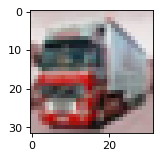

In [7]:
#set index to pull out an image
idx = 8000

#pull out image and label 
ex = b2_mod[b'data'][idx]
ex_label = b2_mod[b'labels'][idx]

#resize image from CIFAR10 data into 3-D numpy array -- note here that numpy follows (depth, rows, columns) nomenclature
ex_new = np.reshape(ex, (3,32,32))
# print(ex_new.shape)
# print(ex.shape)

#prints label and the image
print(label_map[ex_label])
plt.figure(figsize = (2,2), dpi = 80)
plt.imshow(ex_new.transpose(1, 2, 0))
plt.show()

## Step 3: Writing a KNN Classifier

### Step 3.1: Data Normalization

In [30]:
#running pre-processing in batches
def normalize_data(batch):
    batch_train = batch[b'data']
    batch_train_mean = batch_train.mean(axis=1).reshape(batch_train.shape[0],1)
    # print(batch_train_mean.shape)
    batch_train_var = batch_train.var(axis=1).reshape(batch_train.shape[0],1)
    # print(batch_train_var.shape)
    batch_train_x = (batch_train - batch_train_mean)/np.sqrt(batch_train_var)
    print(batch_train_x.shape)
    print(np.round(batch_train_x.mean(axis = 1).max(),2))
    print(np.round(batch_train_x.var(axis = 1).min(),2))
    print(np.round(batch_train_x.var(axis = 1).max(),2))
    return batch_train_x, batch_train_mean, batch_train_var

In [32]:
b1_mod_train_x = normalize_data(b1_mod)[0]
b2_mod_train_x = normalize_data(b2_mod)[0]
b3_mod_train_x = normalize_data(b3_mod)[0]
b4_mod_train_x = normalize_data(b4_mod)[0]
b5_mod_train_x = normalize_data(b5_mod)[0]

(10000, 3072)
0.0
1.0
1.0
(10000, 3072)
0.0
1.0
1.0
(10000, 3072)
0.0
1.0
1.0
(10000, 3072)
0.0
1.0
1.0
(10000, 3072)
0.0
1.0
1.0


In [44]:
b1_mod_train_y = np.array(b1_mod[b'labels'], dtype = np.int8)
b2_mod_train_y = np.array(b2_mod[b'labels'], dtype = np.int8)
b3_mod_train_y = np.array(b3_mod[b'labels'], dtype = np.int8)
b4_mod_train_y = np.array(b4_mod[b'labels'], dtype = np.int8)
b5_mod_train_y = np.array(b5_mod[b'labels'], dtype = np.int8)

In [46]:
#qc
print(b1_mod_train_y.shape)
print(b1_mod_train_y.dtype)

(10000,)
int8


### Step 3.2 Writing a KNN classifier

In [170]:
class KNearestNeighbour(object):
    
    def __init__(self):
        pass
    
    #at train time, the KNN classifier just remembers all data
    def train(self, x, y):
        self.x_train = x
        self.y_train = y

    def test(self, x_test, distance = 'L1'):
        self.x_test = x_test
        
        #reshapes train
        reshape_train_axis = 1, self.x_train.shape[0] , self.x_train.shape[1]
        replicate_train_axis = self.x_test.shape[0], 1 , 1
        reshape_train = np.tile(self.x_train.reshape(reshape_train_axis), replicate_train_axis)
            
        #reshapes test
        reshape_test_axis = self.x_test.shape[0], 1 , self.x_test.shape[1]
        replicate_test_axis = 1, self.x_train.shape[0], 1
        reshape_test = np.tile(self.x_test.reshape(reshape_test_axis), replicate_test_axis)
        
        if distance == 'L1':
            #compute L1 distance over all examples in the training set - use vectorized code instead of loops
            dist_matrix = np.abs(reshape_train - reshape_test)
            dist_matrix_sum = dist_matrix.sum(axis = 2)
            idx_least_dist = np.argmin(dist_matrix_sum, axis = 1)
            y_pred = self.y_train[idx_least_dist]
            
            return y_pred
            
        if distance == 'L2':
            #compute L2 distance over all examples in the training set - use vectorized code instead of loops
            dist_matrix = (reshape_train - reshape_test)**2
            dist_matrix_sum = np.sqrt(dist_matrix.sum(axis = 2))
            idx_least_dist = np.argmin(dist_matrix_sum, axis = 1)
            y_pred = self.y_train[idx_least_dist]
            
            return y_pred

In [171]:
knn = KNearestNeighbour()
knn.train(b1_mod_train_x, b1_mod_train_y)
print(knn.test(b2_mod_train_x[100:105], distance = 'L2'))
print(b2_mod_train_y[100:105])

[1 6 8 7 2]
[1 3 8 8 5]


### Step 3.3 Cross Validation

### Step 3.4 KNearest Neighbor with k>1 (voting mechanism)

In [172]:
# Initial 5x3072 matrix
original_matrix = np.random.rand(2, 3)
original_matrix

array([[0.94202373, 0.64208919, 0.99123476],
       [0.69159636, 0.94631199, 0.00150213]])

In [124]:
new_mat = np.tile(original_matrix.reshape(2, 1, 3), (1, 2, 1))
print(new_mat.shape)
print(new_mat)

(2, 2, 3)
[[[0.85072514 0.88462347 0.33269664]
  [0.85072514 0.88462347 0.33269664]]

 [[0.35521831 0.87925134 0.43011866]
  [0.35521831 0.87925134 0.43011866]]]
